In [142]:
import numpy as np
import torch
import torchvision
from torch.utils.data import dataloader
import torchvision.transforms.functional as TF

from tqdm import tqdm
import mlflow
import os
import matplotlib.pyplot as plt

In [143]:
import cv2
from dataset import mask_to_centers, DOTA_MEAN, DOTA_STD
from inference import draw_centers, load_checkpoint, predict_sliding_window, find_peaks, compute_metrics_at_threshold, match_centers, get_gaussian_weight_map
from loss import CenterLoss

In [144]:
RANDOM_STATE = 1619
TILE_SIZE = 512
STRIDE = 384
THRESHOLD = 0.3
MATCH_RADIUS = 20.0

In [145]:
device ="mps" if torch.backends.mps.is_available() else  "cuda" if torch.cuda.is_available() else "cpu"

In [146]:
## mlflow set-up
experiment_name = "co-patch-attack-trial1"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='/Users/co/Code/projet-vision/mlruns/1', creation_time=1771274040764, experiment_id='1', last_update_time=1771274040764, lifecycle_stage='active', name='co-patch-attack-trial1', tags={}>

In [147]:
# Init the attack
img_path = "segdata/DOTA/DOTA_PLANES_TILED/train/image/P0023_obj_27.png"
mask_path = "segdata/DOTA/DOTA_PLANES_TILED/train/mask/P0023_obj_27.png"
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
gt_centers = mask_to_centers(gt_mask * 255)

base_features = torch.load("segdata/DOTA/DOTA_PLANES_TILED_CACHED_FEATURES/base/train/P0022_obj_6.pt")

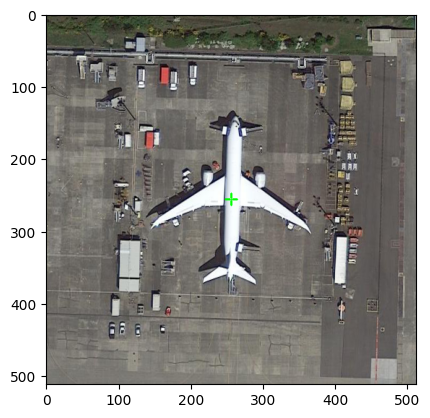

In [148]:
thickness = max(2, int(max(img.shape[:2]) / 500))
radius = max(8, int(max(img.shape[:2]) / 200))
vis_gt = draw_centers(img, gt_centers, (0, 255, 0), radius=radius, thickness=thickness)
plt.imshow(vis_gt)

In [149]:
# load the model
ckpt_path = "runs/16_02-21_05_12_BASE_animal-variation.pth"
model = load_checkpoint(ckpt_path, device)
model.eval();


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

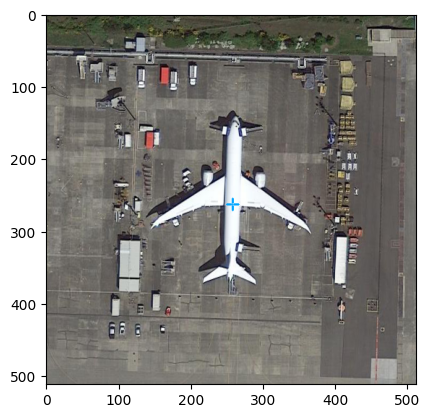

In [150]:
# Predict:
prob_map = predict_sliding_window(model, img, device=device)
pred_centers = find_peaks(prob_map, threshold=THRESHOLD)
heatmap = prob_map
vis_pred = draw_centers(img, pred_centers, (0, 165, 255), radius=radius, thickness=thickness)
plt.imshow(vis_pred)

In [151]:
tp, fp, fn = match_centers(gt_centers, pred_centers)
print("TP = ", tp, "| FP = ", fp, "| FN = ", fn)

TP =  1 | FP =  0 | FN =  0


## Naive Attack

In [152]:
# Add Patch on the top corner
PATCH_SIZE = 72
patch = np.zeros_like(img)
patch[0:PATCH_SIZE, 0:PATCH_SIZE] = 1
weight_map = get_gaussian_weight_map(TILE_SIZE, device)

In [153]:
def predict(model, x, weight_map, device):
    x_t = torch.from_numpy(x).permute(2, 0, 1).float() / 255.0
    x_t = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x_t = x_t.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x_t)
        prob = torch.sigmoid(logits).squeeze()
        
    prob_map = (prob * weight_map).cpu().numpy()
    print("Maximum Prob = ", prob_map.max().max())

    return prob_map

In [372]:
def show_attack_results(x0, x, y0, y):
    
    y0_centers = find_peaks(y0, threshold=THRESHOLD)
    prediction0 = draw_centers(x0, y0_centers, (0, 165, 255), radius=radius, thickness=thickness)

    y_centers = find_peaks(y, threshold=THRESHOLD)
    prediction = draw_centers(x, y_centers, (0, 165, 255), radius=radius, thickness=thickness)

    ## Normalization
    # Make x and vis_pred float [0,1] too (if they are uint8 or 0..255 float)
    prediction0 = prediction0.astype(np.float32) / 255.0
    prediction = prediction.astype(np.float32) / 255.0

    # Normalize prob_map to [0,1]
    y0_f = y0.astype(np.float32)
    pmin0, pmax0 = y0_f.min(), y0_f.max()
    y0_f_norm = (y0_f - pmin0) / (pmax0 - pmin0 + 1e-8)
    # Colormap returns float in [0,1]
    y0_color = plt.get_cmap("magma")(y0_f_norm)[..., :3]
    
    # Normalize prob_map to [0,1]
    y_f = y.astype(np.float32)
    pmin, pmax = y_f.min(), y_f.max()
    y_f_norm = (y_f - pmin) / (pmax - pmin + 1e-8)
    # Colormap returns float in [0,1]
    y_color = plt.get_cmap("magma")(y_f_norm)[..., :3]
    
    fig, ax = plt.subplots(2,2, figsize=(12,12))
    y0_max = y0.max()
    y_max = y.max()
    
    ax[0,0].imshow(prediction0)
    ax[0,0].set_title(f"Original Image and Prediction | Max = {y0_max:.2f}")
    ax[0,1].imshow(y0_color)
    ax[0,1].set_title("Original Prob")
    ax[1,0].imshow(prediction)
    ax[1,0].set_title(f"Attacked Image and Prediction | Max = {y_max:.2f}")
    ax[1,1].imshow(y_color)
    ax[1,1].set_title("Attacked  Prob")

    for ax in fig.axes:
        ax.axis("off")
    plt.show()

Maximum Prob =  0.5778244
Maximum Prob =  0.5680766


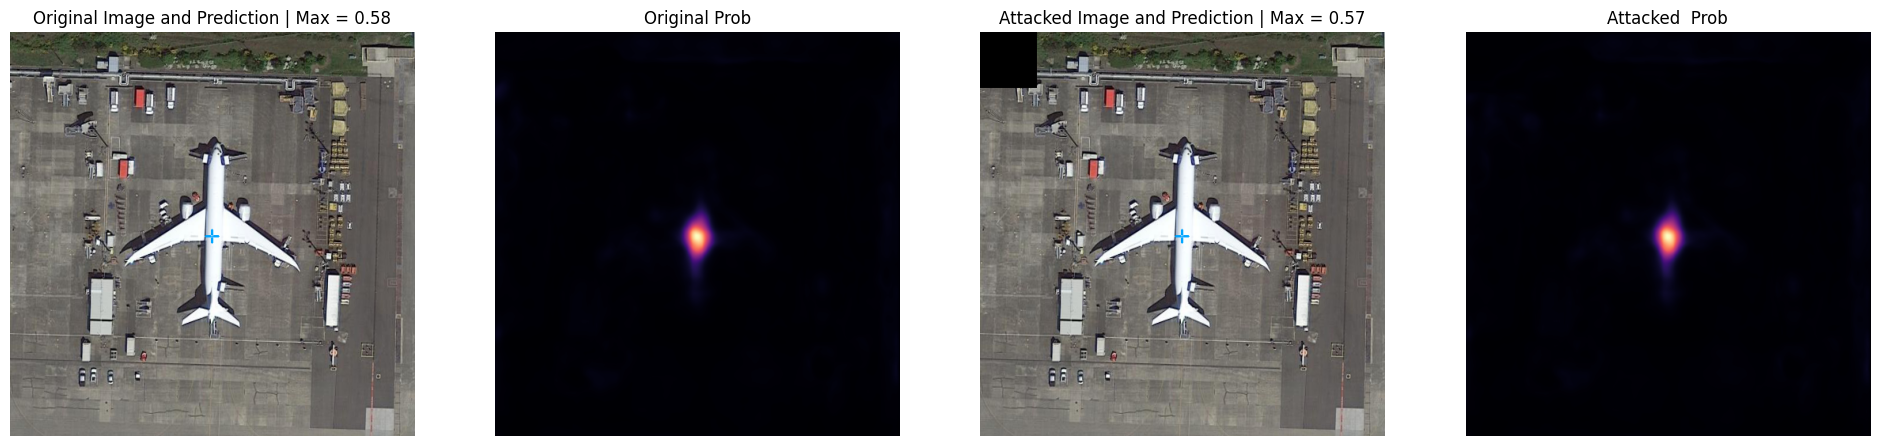

In [234]:
x0 = img
x = x0*(1-patch)
y0 = predict(model, x0, weight_map, device)
y = predict(model, x, weight_map, device)
show_attack_results(x0, x, y0, y)

## Iteration of First Attack

In [140]:
def x_to_torch(x):
    x_t = torch.from_numpy(x).permute(2, 0, 1).float() / 255.0
    x_t = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x_t = x_t.unsqueeze(0).to(device)
    return x_t

In [161]:
def normalize(x_t):
    x = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
    x = x.unsqueeze(0).to(device)
    return x

In [ ]:
min = torch.normalize(torch.zeros_like(x0_t)

tensor(1., device='mps:0')

In [263]:
cefunction = CenterLoss().to(device)
x0_t = x_to_torch(x0)

with torch.no_grad():
  y0_t = model(x0_t)
  x_min, x_max = x0_t.min().item(), x0_t.max().item()
  
attack_init = torch.nn.Parameter(torch.rand_like(x0_t))

patch_t = torch.zeros_like(x0_t).to(device)
patch_t[:,:,0:PATCH_SIZE,0:PATCH_SIZE] = 1

# weight_map_t = torch.from_numpy(weight_map)
attack = torch.nn.Parameter(attack_init.clone())
optimizer = torch.optim.AdamW([attack], lr=0.5)

for i in range(100):
    optimizer.zero_grad()

    x_attacked = x0_t * (1 - patch_t) + attack * patch_t
    y_attacked = torch.sigmoid(model(x_attacked)) * (1-weight_map)
    ce = cefunction(y_attacked, y0_t)

    print(i, float(ce))
    loss = -ce
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        attack.clamp_(x_min*1.5, x_max*1.5)  # keeps it in image range, no new graph

# Double backward error
# for i in range(2):
#   optimizer.zero_grad()
#   x_attacked = x0_t*(1-patch_t)+attack*patch_t
#   y_attacked = torch.sigmoid(model(x_attacked))*weight_map # optimize only the attack
#   ce = cefunction(y_attacked,y0_t)
#   print(i,float(ce))
#   ce = -ce # on veut MAXIMISER la cross entropy puisqu'on attaque
#   ce.backward()
#   #attack.grad = attack.grad.sign()
#   optimizer.step()
# #   with torch.no_grad():
# #       # l'attaque doit être dans le domaine image
# #       attack = torch.clamp(attaque, 0,1)
#   attack = attack.detach().requires_grad_(True)
#   attack = torch.nn.Parameter(attack.clone())
# #   if i<20:
# #       optimizer = torch.optim.SGD([attack],lr=0.1)
# #   else:
# #       optimizer = torch.optim.SGD([attack],lr=0.05)

0 103.06681823730469
1 103.07760620117188
2 103.10903930664062
3 103.19554901123047
4 103.44093322753906
5 103.45158386230469
6 103.67021179199219
7 103.79688262939453
8 103.89197540283203
9 103.95068359375
10 104.02384948730469
11 104.13818359375
12 104.39886474609375
13 104.75811767578125
14 104.60172271728516
15 106.01441955566406
16 106.25497436523438
17 108.7026596069336
18 108.59695434570312
19 109.40396881103516
20 110.2491455078125
21 112.5671615600586
22 114.21903991699219
23 114.96757507324219
24 114.3769760131836
25 115.32254791259766
26 115.56996154785156
27 117.00006103515625
28 119.0892562866211
29 121.12615966796875
30 121.95960235595703
31 123.26889038085938
32 124.62049865722656
33 126.05433654785156
34 127.14472961425781
35 128.38888549804688
36 129.21253967285156
37 129.9109649658203
38 130.0878448486328
39 130.87332153320312
40 131.90774536132812
41 133.10646057128906
42 133.38429260253906
43 133.55152893066406
44 134.8827362060547
45 135.8570098876953
46 135.722610

In [264]:
mean = torch.tensor(DOTA_MEAN, device=device).view(1, 3, 1, 1)
std = torch.tensor(DOTA_STD, device=device).view(1, 3, 1, 1)

x_attacked_un = (x_attacked * std + mean)
x_attacked_un = (x_attacked_un + x_attacked_un.min())/(x_attacked_un.min()+x_attacked_un.max())*255
img_attacked = x_attacked_un.cpu().detach().numpy().squeeze().transpose(1,2,0)
prediction_attacked = y_attacked.cpu().detach().numpy().squeeze()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45854363..1.0].


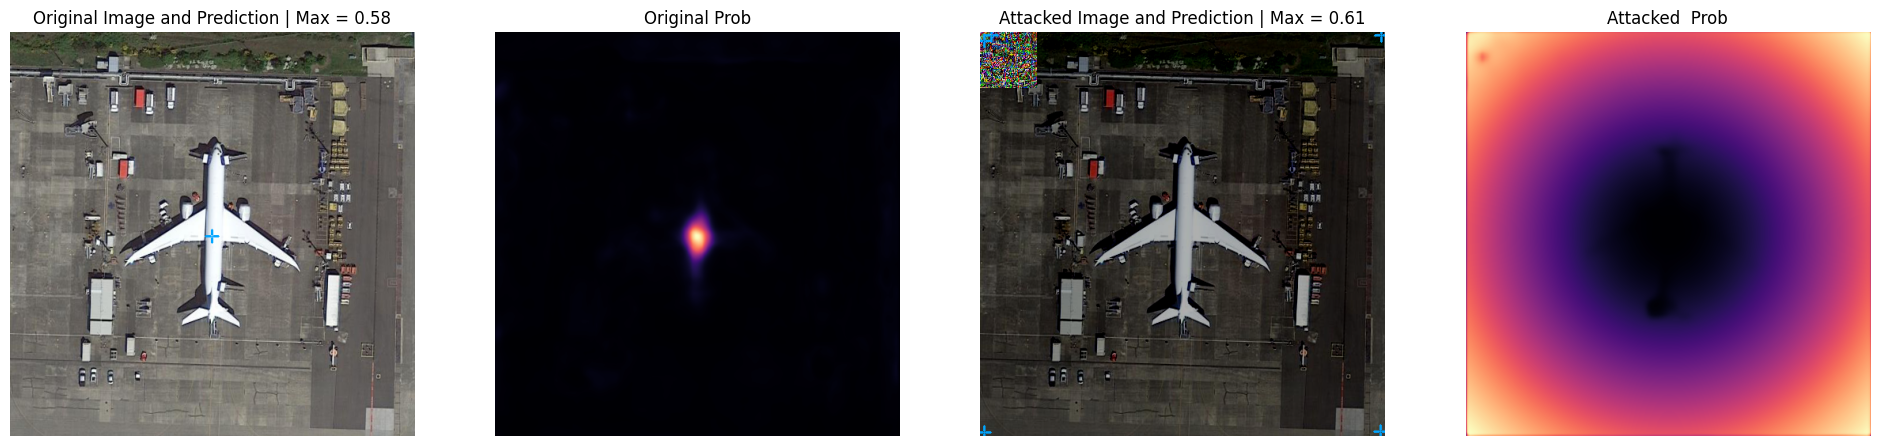

In [265]:
show_attack_results(x0, img_attacked, y0,prediction_attacked )

## Second Attack 

In [ ]:

max


tensor([[[[2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532],
          [2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532],
          [2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532],
          ...,
          [2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532],
          [2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532],
          [2.8532, 2.8532, 2.8532,  ..., 2.8532, 2.8532, 2.8532]],

         [[2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105],
          [2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105],
          [2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105],
          ...,
          [2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105],
          [2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105],
          [2.9105, 2.9105, 2.9105,  ..., 2.9105, 2.9105, 2.9105]],

         [[3.1300, 3.1300, 3.1300,  ..., 3.1300, 3.1300, 3.1300],
          [3.1300, 3.1300, 3.1300,  ..., 3.1300, 3.1300, 3.1300],
          [3.1300, 3.1300, 3.1300,  ..., 3

In [426]:
x0_t.max()

tensor(3.1300, device='mps:0')

In [ ]:
cefunction = CenterLoss().to(device)
x0_t = x_to_torch(x0)

min = TF.normalize(torch.zeros_like(x0_t), DOTA_MEAN, DOTA_STD)
max = TF.normalize(torch.ones_like(x0_t), DOTA_MEAN, DOTA_STD)

with torch.no_grad():
  y0_t = torch.sigmoid(model(x0_t))
  
attack_init = torch.nn.Parameter(torch.rand_like(x0_t))

patch_t = torch.zeros_like(x0_t).to(device)
patch_t[:,:,0:PATCH_SIZE,0:PATCH_SIZE] = 1

# weight_map_t = torch.from_numpy(weight_map)
attack = torch.nn.Parameter(attack_init.clone())
optimizer = torch.optim.AdamW([attack], lr=0.5)

for i in range(20):
    optimizer.zero_grad()

    x_attacked = x0_t * (1 - patch_t) + attack * patch_t
    y_attacked = torch.sigmoid(model(x_attacked))#* weight_map
    ce = cefunction(y0_t, y_attacked)
    # ce = cefunction(y0_t * (1-weight_map), y_attacked)

    print(i, float(ce))
    loss = -ce
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        attack.clamp_(min, max)  # keeps it in image range, no new graph


0 0.20552650094032288
1 0.20543238520622253
2 0.20555642247200012
3 0.2054591178894043
4 0.20570841431617737
5 0.2059924304485321
6 0.20635470747947693


In [ ]:
def numpyfy_attack_results(x_attacked, y_attacked):
    mean = torch.tensor(DOTA_MEAN, device=device).view(1, 3, 1, 1)
    std = torch.tensor(DOTA_STD, device=device).view(1, 3, 1, 1)

    x_attacked_un = (x_attacked * std + mean)
    x_min, x_max = (x_attacked_un*(1-patch_t)).min(), (x_attacked_un*(1-patch_t)).max()
    x_attacked_un = (x_attacked_un + x_min)/(x_min+ x_max)*255
    img_attacked = x_attacked_un.cpu().detach().numpy().squeeze().transpose(1,2,0)
    prediction_attacked = y_attacked.cpu().detach().numpy().squeeze()
    
    return img_attacked, prediction_attacked

In [ ]:
at = attack.cpu().detach().numpy().squeeze().transpose(1,2,0)
x = x0 * (1 - patch) + at * patch
y = predict(model, x, weight_map, device)
y.max()

Maximum Prob =  0.56235254


0.56235254

In [ ]:
img_not_attacked, prediction_not_attacked = numpyfy_attack_results(x0_t, y0_t*weight_map)

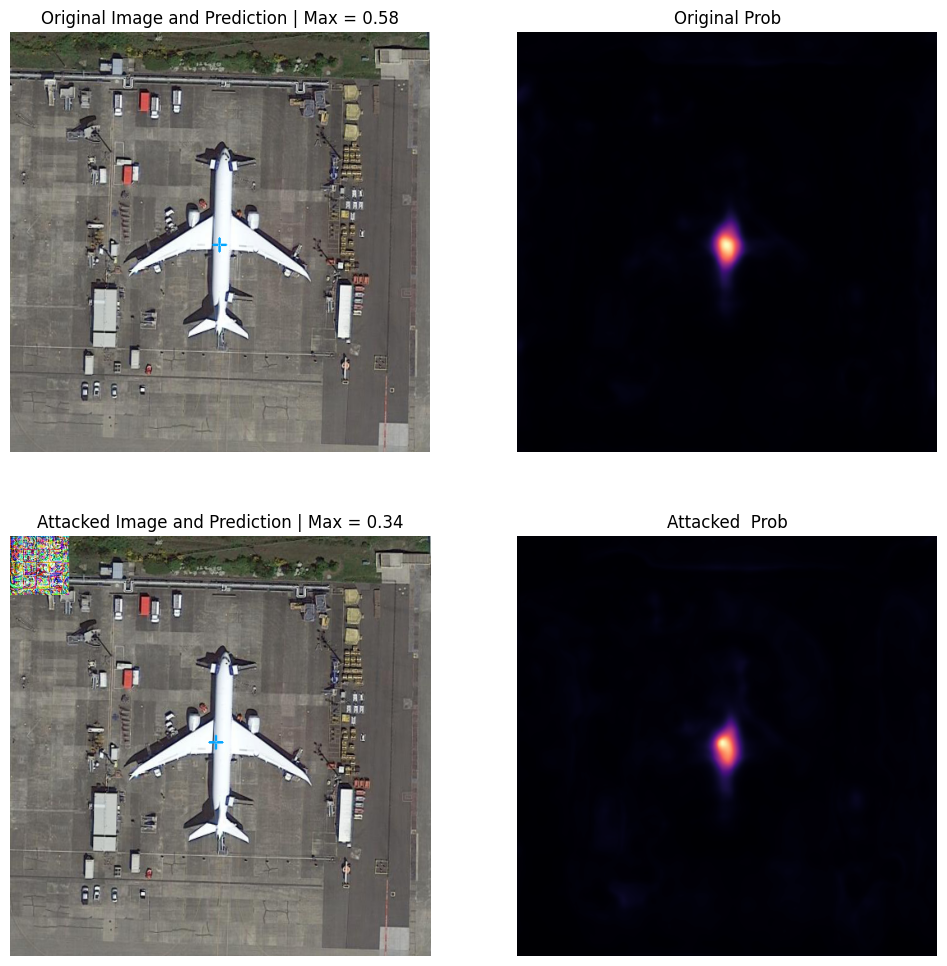

In [ ]:
img_attacked, prediction_attacked = numpyfy_attack_results(x_attacked, y_attacked*weight_map)
show_attack_results(img_not_attacked, img_attacked, prediction_not_attacked, prediction_attacked )

### 